# Pseudo-Synchronization

This adds self consistent spin, tidal and dynamical equations of motion in the equilibrium tide model as outlined by Eggleton et. al (1998). In this simple example we confirm the prediction of pseudo-synchronization for a fiducial hot Jupiter. This example can be seen in Millholland & Laughlin (2019) and is Figure 2 in Lu et al. (2023).

The notebook includes a great deal of spin vector manipulation. For more in-depth examples on manipulating spins in REBOUNDx, see `SpinsIntro.ipynb`. For more information on REBOUND's general Rotations framework, see `Rotations.ipynb` in the REBOUND directory.

In [1]:
import rebound
import reboundx
import numpy as np
import matplotlib.pyplot as plt

We'll set up the system in the traditional REBOUND framework first. We set up a fiducial hot Jupiter in a near-circular orbit around a solar-type star

In [2]:
sim = rebound.Simulation()
# Star
ms = 1
rs = 0.00465
sim.add(m = ms, r = rs)

# Planet
mp = 9.55e-4
rp = 4.676e-4
ap = 0.04072
ep = 0.01
sim.add(m = mp, r = rp, a = ap, e = ep)
ps = sim.particles

Now, we add the extra parameters necessary to calculate the spin and tidal effects. Let's first set the Love numbers and moment of inertias. While only the Love number is strictly necessary, the moment of inertia should also be set - otherwise the spin axis will not evolve and you won't see any interesting behavior.

In [3]:
rebx = reboundx.Extras(sim)
sf = rebx.load_force("tides_spin")
rebx.add_force(sf)

# Star parameters
ps[0].params['k2'] = 0.07
ps[0].params['I'] = 0.07 * ms * rs**2 # if m=0, the effect interprets 'I' as I/m, so we could set ...['I'] = 0.07*rs**2

# Planet parameters
ps[1].params['k2'] = 0.3
ps[1].params['I'] = 0.25 * mp * rp**2

/Users/dtamayo/Documents/workspace/rebound/rebound/simulation.py:264: RuntimeWarning: tides_spin was updated in version 4.5.0 to halve the acceleration from the conservative piece of the tidal potential, reflecting a typo discovered in Eggleton et. al (1998). This warning will be removed in a future version.

  warnings.warn(msg[1:], RuntimeWarning)


Next we initialize the spin axes. While these can be set directly, the spin axis is most naturally thought of as a vector with magnitude equal to the angular spin frequency, and orientation described by two angles: obliquity $\theta$ the polar angle from the orbit normal, and phase angle $\phi$ the azimuthal angle from the line of ascending node. 

Since we initialized our hot Jupiter on an orbit with $0$ inclination, the orbit normal and line of ascending node correspond to the $z$ and $x$ axes, respectively. Let's initialize the star with $0$ obliquity, and the planet with $30^\circ$. We can either set the Cartesian elements directly, or use a REBOUND convenience function.

In [4]:
# Star's spin axis
spin_period_star = (27 / 365) * 2 * np.pi # 27 days in default REBOUND units
spin_mag_star = 2 * np.pi / spin_period_star
obliquity_star = 0
phase_star = 0

# The convenience function
ps[0].params['Omega'] = rebound.spherical_to_xyz(magnitude=spin_mag_star, theta=obliquity_star, phi=phase_star)

# To set the spin vector directly in Cartesian coordinates. Both approaches are equivalent
# ps[0].params['Omega'] = [spin_mag_star * np.sin(obliquity_star) * np.cos(phase_star),
# spin_mag_star * np.sin(obliquity_star) * np.sin(phase_star), spin_mag_star * np.cos(obliquity_star)] 

# Planet's spin axis
spin_period_planet = (0.5 / 365) * 2 * np.pi # 0.5 days in default REBOUND units
spin_mag_planet = 2 * np.pi / spin_period_planet
obliquity_planet = np.radians(30.0)
phase_planet = 0

ps[1].params['Omega'] = rebound.spherical_to_xyz(magnitude=spin_mag_planet, theta=obliquity_planet, phi=phase_planet)

Finally, we can set the constant time lag $\tau$, which sets the rate of tidal dissipation. Often, tidal dissipation is also parametrized in terms of the tidal quality factor Q. These are simply related for the particular case of synchronized, circular orbits (see Section 2 of Lu et. al (2023) for more discussion), in which case

$Q^{-1} \sim 2 n \tau$

where $n$ is the mean motion of the planet around the star (for both the stellar and planet Q)

In [5]:
stellar_Q = 1e6
planet_Q = 1e4

ps[0].params['tau'] = 1 / (2 * stellar_Q * ps[1].n)
ps[1].params['tau'] = 1 / (2 * planet_Q * ps[1].n)

Some bookkeeping before we begin integrating the system: choosing an integrator, moving to the CoM, and aligning the system to the invariant plane (which aligns the spins as well as the orbits of the bodies)

In [6]:
sim.integrator = "whfast"
sim.dt = sim.particles[1].P/10.1234567 # timestep is a fraction of the orbital period
sim.move_to_com() # Moving to CoM

Ltot = np.array(sim.angular_momentum()) + np.array(rebx.spin_angular_momentum())
rot = rebound.Rotation.to_new_axes(newz=Ltot) # Alignment to invariant plane
rebx.rotate_simulation(rot)

The next step is mandatory: to track the evolution of the spin axis, you MUST call the function `initialize_spin_ode`. Otherwise the spin axis will remain stationary and you won't see anything interesting! Call this function after all parameters have been set and all rotations and frame changes are complete.

**You must also call `initialize_spin_ode` if you ever reload the Simulation and rebx from a binary to set all the function pionters correctly.**

In [7]:
rebx.initialize_spin_ode(sf)

Now, we integrate. We'll track the hot Jupiters's spin axis, semimajor axis, and eccentricity.

Note that the spin axis has been tracked in the inertial reference frame, which we have aligned with the invariant plane of the system. It is often much more useful to calculate the spin vector relative to the planet's orbit normal, which we can find with `ps[1].hvec`. Here we'll interpret the results in this frame.

In [8]:
%%time
tmax = 2 * np.pi * 1e4
Nout = 1000
times = np.linspace(0, tmax, Nout)

planet_a = np.zeros(Nout)
planet_e = np.zeros(Nout)

planet_spin_mag = np.zeros(Nout)
planet_obliquity = np.zeros(Nout)
planet_phase = np.zeros(Nout)

for i, t in enumerate(times):
    # Orbital elements
    planet_a[i] = ps[1].a
    planet_e[i] = ps[1].e
    
    # Spin Axis
    planet_spin_axis_inv = ps[1].params['Omega'] # Initially invarant frame
    
    planet_orbit_normal = ps[1].hvec
    rot_to_orbit_frame = rebound.Rotation.to_new_axes(newz=planet_orbit_normal)
    planet_spin_axis_orb = rot_to_orbit_frame * planet_spin_axis_inv # Now in the planet frame
    
    # We can interpret the spin axis in the more natural spherical coordinates
    mag, obliquity, phase = rebound.xyz_to_spherical(planet_spin_axis_orb)
    
    planet_spin_mag[i] = mag
    planet_obliquity[i] = np.degrees(obliquity)
    planet_phase[i] = np.degrees(phase)
    
    sim.integrate(t)

/Users/dtamayo/Documents/workspace/rebound/rebound/simulation.py:264: RuntimeWarning: REBOUNDx: Passing a velocity-dependent force to WHFAST, will accumulate errors proportional to the force. If forces get big, consider using IAS15 or applying force as an operator. See REBOUNDx paper sec 5.1 and ipython_examples/IntegrateForce.ipynb.
  warnings.warn(msg[1:], RuntimeWarning)


CPU times: user 11.6 s, sys: 16.8 ms, total: 11.6 s
Wall time: 11.6 s


Let's compare this to analytic results. We'll numerically integrate the same initial conditions with the orbit-averaged expressions from Leconte et. al (2010), which is an equivalent framework to ours.

In [9]:
from scipy.integrate import odeint

def leconte_analytic(params, t, mstar, rstar, k2_star, dt_star, C_s, mp, rp, k2_p, dt_p, C_p):
    '''
    Leconte 2010 Eq (2, 6, 10)
    Assumes REBOUND units (G=1)
    '''
    
    a, e, omega_p, omega_s, ep_p, ep_s = params
    n = np.sqrt((mstar + mp) / a**3)
    
    n_e = (1 + (15 / 2) * e**2 + (45 / 8) * e**4 + (5 / 16) * e**6) / (1 - e**2)**6
    n_a_e = (1 + (31 / 2) * e**2 + (255 / 8) * e**4 + (185 / 16) * e**6 + (25 / 64) * e**8) / (1 -  e**2)**(15 / 2)
    n_e_e = (1 + (15 / 4) * e**2 + (15 / 8) * e**4 + (5 / 64) * e**6) / (1 - e**2)**(13 / 2)
    omega_e_e = (1 + (3 / 2) * e**2 + (1 / 8) * e**4) / (1 - e**2)**5
    omega_e = (1 + 3 * e**2 + (3 / 8) * e**4) / (1 - e**2)**(9 / 2)
    
    Kp = 3 * k2_p * dt_p * (mp**2 / rp) * (mstar / mp)**2 * (rp / a)**6 * n**2
    Kstar = 3 * k2_star * dt_star * (mstar**2 / rstar) * (mp / mstar)**2 * (rstar / a)**6 * n**2
    
    eta_p = (mp + mstar) / (mp * mstar) * (C_p * omega_p) / (a**2 * n * np.sqrt(1 - e**2))
    eta_s = (mp + mstar) / (mp * mstar) * (C_s * omega_s) / (a**2 * n * np.sqrt(1 - e**2))
    
    da_dt = (4 * a**2 / (mstar * mp)) * (Kp * (n_e * np.cos(ep_p) * omega_p / n - n_a_e)
                                       + Kstar * (n_e * np.cos(ep_s) * omega_s / n - n_a_e))
    
    de_dt = (11 * a * e / (mstar * mp)) * (Kp * (omega_e_e * np.cos(ep_p) * omega_p / n - (18 / 11) * n_e_e)
                                         + Kstar * (omega_e_e * np.cos(ep_s) * omega_s / n - (18 / 11) * n_e_e))
    
    domega_p_dt = -(Kp / (n * C_p)) * ((1 + np.cos(ep_p)**2) * omega_e * omega_p / n - 2 * np.cos(ep_p) * n_e)
    domega_s_dt = -(Kstar / (n * C_s)) * ((1 + np.cos(ep_s)**2) * omega_e * omega_s / n - 2 * np.cos(ep_s) * n_e)
    
    dep_p_dt = np.sin(ep_p) * ((Kp / (n * omega_p * C_p)) * 
                               ((np.cos(ep_p) - eta_p) * omega_e * omega_p / n - 2 * n_e))
    dep_s_dt = np.sin(ep_s) * ((Kstar / (n * omega_s * C_s)) * 
                               ((np.cos(ep_s) - eta_s) * omega_e * omega_s / n - 2 * n_e))
    
    return [da_dt, de_dt, domega_p_dt, domega_s_dt, dep_p_dt, dep_s_dt]

initial_condition = [ap, ep, 365 / 0.5, 365 / 27, np.radians(30.), np.radians(0)]
analytic_solution = odeint(leconte_analytic, initial_condition, times,
                              args=(ms, rs, 0.07, 4.11e-9, 0.07 * ms * rs**2,
                                    mp, rp, 0.3, 4.11e-7, 0.25 * mp * rp**2))

Interpreting and unpacking these results:

In [10]:
# Numeric results
planet_n = np.sqrt((ms + mp) / (planet_a**3))

# Analytic results
planet_lec_a = analytic_solution[:,0]
planet_lec_e = analytic_solution[:,1]
planet_lec_n = np.sqrt((ms + mp) / (planet_lec_a**3))
planet_lec_spin = analytic_solution[:,2]
planet_lec_obliquity = np.degrees(analytic_solution[:,4])

Below we have overplotted both the numeric results from our REBOUND simulation, and the analytic results from the Leconte et. al (2010) equations. This reproduces Figure 2 in Lu et. al (2023).

Text(0.5, 0, 'Time (kyr)')

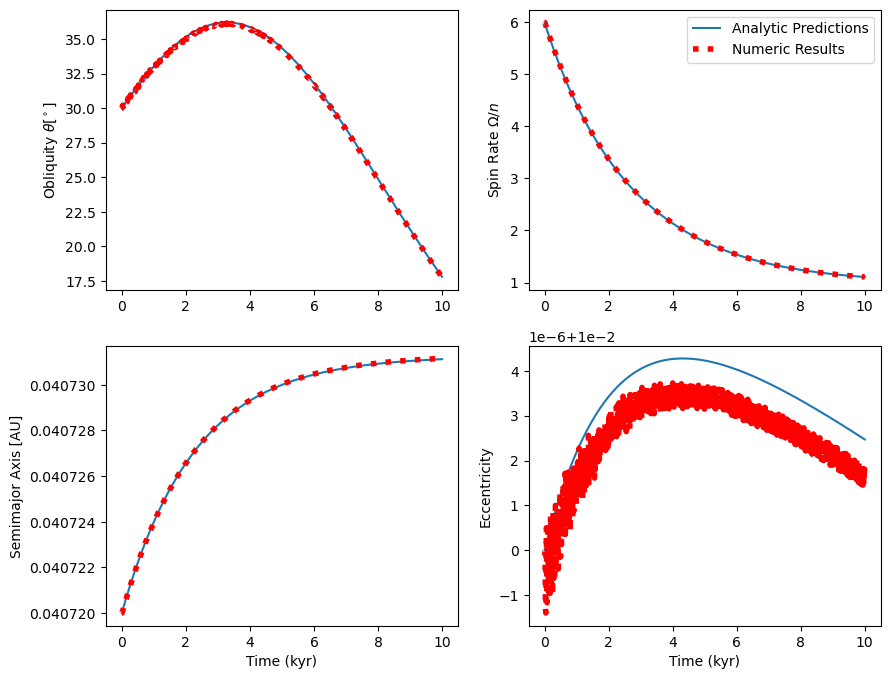

In [11]:
fig, ax = plt.subplots(2,2,figsize=(10,8))
ax = ax.ravel()

times_rescaled = times / (1000 * 2 * np.pi) # this converts from REBOUND time units to kyr

ax[0].plot(times_rescaled, planet_lec_obliquity)
ax[0].plot(times_rescaled, planet_obliquity, ls = ':', color = 'red', linewidth=4)
ax[0].set_ylabel(r'Obliquity $\theta [^\circ]$')

ax[1].plot(times_rescaled, planet_lec_spin / planet_lec_n, label = 'Analytic Predictions')
ax[1].plot(times_rescaled, planet_spin_mag / planet_n, ls = ':', color = 'red', lw=4, label='Numeric Results')
ax[1].set_ylabel(r'Spin Rate $\Omega / n$')
ax[1].legend()

ax[2].plot(times_rescaled, planet_lec_a)
ax[2].plot(times_rescaled, planet_a, ls = ':', color = 'red', lw=4)
ax[2].set_ylabel('Semimajor Axis [AU]')
ax[2].set_xlabel('Time (kyr)')

ax[3].plot(times_rescaled, planet_lec_e)
ax[3].plot(times_rescaled, planet_e, ls = ':', color = 'red', lw=4)
ax[3].set_ylabel('Eccentricity')
ax[3].set_xlabel('Time (kyr)')

Clearly, the numeric and analytic results are in excellent agreement! The only noticable difference is in the eccentricity evolution, in which numeric and analytic results vary by less than 0.03% over the course of the evolution!